In [179]:
import time

import numpy as np

from scipy import special, spatial

from IPython import display

import sympy
from sympy.printing.numpy import SciPyPrinter

from astropy import units as u

In [180]:
from matplotlib import pyplot as plt 

In [181]:
import nautilus 
import corner

See [green_integral_circular_sersic_simulations.ipynb](green_integral_circular_sersic_simulations.ipynb) for some starting points

# Helper functions

In [182]:
BN_ICOEFFS = [2, -1/3, 4/405, 46/25515, 131/1148175, -2194697/30690717750]

def f_bn(n):
    """
    Ciotti and Bertin 99, valid for n >~ 0.36
    """
    return np.sum([C*n**(1-i) for i, C in enumerate(BN_ICOEFFS)], axis=0)

def sersic_profile(R, Ie, Re, n):
    bn = f_bn(n)
    return Ie * np.exp(-bn*((R/Re)**(1/n)-1))

def log_sersic_profile(R, Ie, Re, n):
    bn = f_bn(n)
    return np.log(Ie) - bn*((R/Re)**(1/n)-1)

In [183]:
def sersic_distribution(U, Re, n, Router=np.inf):
    bn = f_bn(n)

    #Iemax = 1/finteg(Router, Re, n, bn, 1)
    integral = Re**2*bn**(-2*n)*n*np.exp(bn)*special.gamma(2*n)*special.gammainc(2*n, Re**(-1/n)*bn*Router**(n**(-1.0)))
    IEmax = 1/integral

    #sympy_gamma =  U*bn**(2*n)*np.exp(-bn)/(Iemax*Re**2*n)
    sympy_gamma =  U*bn**(2*n)*np.exp(-bn)/(Re**2*n) * integral

    gamma_arg = special.gammaincinv(2*n, sympy_gamma / special.gamma(2*n))
    return Re*(gamma_arg/bn)**n

In [184]:
def dimensionless_path_integrand(x, y, Δx, Δy, Re, n):
    bn = f_bn(n)
    Rsq = x*x + y*y
    twon = 2*n
    segments = Re**2*bn**(-twon)*n*(x*Δy - y*Δx)*np.exp(bn)*special.gamma(twon)*special.gammainc(twon, Re**(-1/n)*bn*Rsq**(1/twon))/Rsq
    return np.sum(segments)

def sersic_integrate_hull(hull, n_per_segment, n, Re):
    vertxys = hull.points[hull.vertices].T
    edgexys = np.linspace(vertxys, np.roll(vertxys,-1, axis=-1), n_per_segment).T
    integral_of_segments = [dimensionless_path_integrand(x, y, x[1]-x[0], y[1]-y[0], Re=Re, n=n) for x,y in edgexys]
    return np.sum(integral_of_segments)

## Data simulation

Note: Re here is interpreted as the *geometric mean* of *a* and *b*

In [235]:
def sersic_plus_uniform_circle(ntotal, fbkg, n, Re=1, Router=10, x0=0, y0=0, flattening=0, pa=0*u.deg):
    nbkg = int(ntotal*fbkg)
    nfg = ntotal - nbkg

    bovera = 1-flattening
    a = Re/np.sqrt(bovera)
    b = a*bovera

    r_bkg = np.sqrt(np.random.rand(nbkg))*Router
    θ_bkg = np.random.rand(nbkg)*2*np.pi

    x_bkg = r_bkg*np.cos(θ_bkg)
    y_bkg = r_bkg*np.sin(θ_bkg)

    r_fg = sersic_distribution(np.random.rand(nfg), a, n, Router)
    θ_fg = np.random.rand(nfg)*2*np.pi

    x_fg = r_fg*np.cos(θ_fg) * bovera
    y_fg = r_fg*np.sin(θ_fg)

    xp = np.concatenate([x_fg, x_bkg])
    yp = np.concatenate([y_fg, y_bkg])

    spa = np.sin(pa)
    cpa = np.cos(pa)
    
    x = xp*cpa + yp*spa
    y = -xp*spa + yp*cpa

    x[:nfg] += x0
    y[:nfg] += y0
    
    return x, y, nfg

The above is adapted from the circular form so lets do some checks

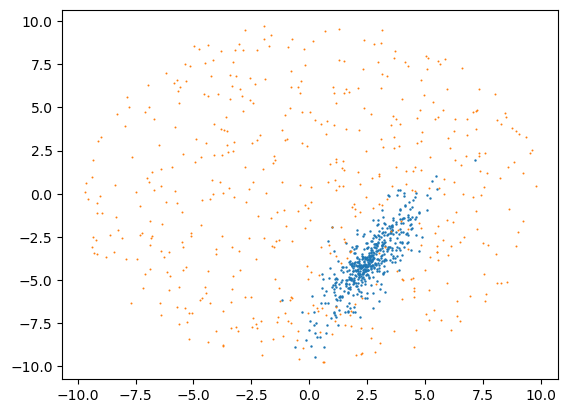

In [238]:
x, y, nfg = sersic_plus_uniform_circle(1000, .5, 1, Re=1, Router=10, x0=2.5, y0=-4, flattening=0.75, pa=30*u.deg)

plt.scatter(x[:nfg], y[:nfg], lw=0, s=3)
plt.scatter(x[nfg-1:], y[nfg-1:], lw=0, s=2)

*IMPORTANT NOTE*: this is the PA convention that assumes x is RA, y is Dec and PA is east of  north (and RA is *non-flipped*)

# Circular to elliptical integral

The integral we're effectively solving (over the hull $H$) is 

$\int_H e^{-r^{\frac{1}{n}}} r dr d \theta $

or

$\int_H e^{-(x'^2 + y'^2)^{\frac{1}{2n}}} dx' dy' $

where

$x = \mathscr{C} x' \cos \phi - y' \sin \phi, y = \mathscr{C} x' \sin \phi + y' \cos \phi $

and 

$ \mathscr{C} \equiv 1 - f =  \frac{b}{a}$ is the circularity parameter (1 when circular, 0 when perfectly elliptical)


In [239]:
x,y,dx,dy,xp,yp,dxp,dyp,phi = sympy.symbols(r"x y dx dy x' y' dx' dy' \phi", real=True)
c, n = sympy.symbols(r"\mathscr{C} n", real=True, positive=True)

In [240]:
xexpr = c*xp*sympy.cos(phi) - yp*sympy.sin(phi)
yexpr = c*xp*sympy.sin(phi) + yp*sympy.cos(phi)
solns = sympy.solve([xexpr - x, yexpr - y], (xp, yp))

for var, expr in solns.items():
    display.display(sympy.Eq(var, expr.simplify()))

Eq(x', (x*cos(\phi) + y*sin(\phi))/\mathscr{C})

Eq(y', -x*sin(\phi) + y*cos(\phi))

In [241]:
jac = sympy.Matrix([xexpr, yexpr]).jacobian([xp, yp])
jac

Matrix([
[\mathscr{C}*cos(\phi), -sin(\phi)],
[\mathscr{C}*sin(\phi),  cos(\phi)]])

In [242]:
jac.det()

\mathscr{C}*sin(\phi)**2 + \mathscr{C}*cos(\phi)**2

which is just $\mathscr{C}$ so

$dx dy = \mathscr{C} dx' dy'$

and the integrand becomes

In [243]:
rsq = (solns[xp]**2 + solns[yp]**2)

rsq.simplify()

(x*sin(\phi) - y*cos(\phi))**2 + (x*cos(\phi) + y*sin(\phi))**2/\mathscr{C}**2

In [244]:
sympy.exp(rsq**(1/(2*n))).simplify()

exp(((x*sin(\phi) - y*cos(\phi))**2 + (x*cos(\phi) + y*sin(\phi))**2/\mathscr{C}**2)**(1/(2*n)))

So a viable solution is to do the integral over the hull *transformed* into primed coordinates and then scale by $\mathscr{C}$, using the a that corresponds to the Re for the actual scale radius.

# Inference on simulated data

''

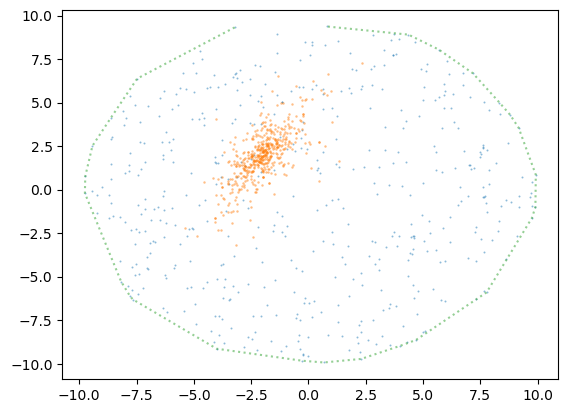

In [ ]:
x0 = -2
y0 = 2
Re = 1
n = 1
fbkg = 0.5
flattening = 0.6
pa=30*u.deg

truths = [x0,y0,Re,n,fbkg,flattening,pa.to_value(u.deg)]

nstars = 1000
Router = 10

x, y, truenfg = sersic_plus_uniform_circle(nstars, fbkg, n=n, Re=Re, Router=Router, x0=x0, y0=y0, flattening=flattening, pa=pa)


xy_hull = spatial.ConvexHull(np.array((x, y)).T)

assert (nstars-truenfg) == fbkg*nstars, f'{nstars-truenfg} != {fbkg*nstars}'

plt.scatter(x[(truenfg-nstars):], y[(truenfg-nstars):], s=2, alpha=0.5, lw=0)
plt.scatter(x[:truenfg], y[:truenfg], s=3, alpha=0.5, lw=0)
plt.plot(*xy_hull.points[xy_hull.vertices].T, ':', alpha=.5, c='C2')
;

In [ ]:
def loglikes(param_dict, data, hull, n_per_segment, noglx=False):
    x0 = param_dict['x0']
    y0 = param_dict['y0']
    Re = param_dict['Re']
    n = param_dict['n']
    fbkg = param_dict['fbkg']

    c = 1 - param_dict['flattening'] # = b/a
    a = Re/np.sqrt(c)

    parad = np.radians(param_dict['pa'])
    cpa = np.cos(parad)
    spa = np.sin(parad)

    xh, yh = hull.points.T
    xph = (xh*cpa + yh*spa)/c
    yph = -xh*spa + yh*cpa

    newhull = spatial.ConvexHull(np.array((xph, yph)).T)

    logbg = -np.log(newhull.volume) #"volume" of a hull is actually 2d area THIS IS THE KEY DIFFERENCE!

    if noglx:
        return logbg*np.ones_like(data[0])
    
    x = data[0] - x0
    y = data[1] - y0

    xp = ((x*cpa - y*spa))/c
    yp =  x*spa + y*cpa
    R = np.hypot(xp, yp)

    logfg = log_sersic_profile(R, 1, a, n) - np.log(sersic_integrate_hull(newhull, n_per_segment, n, a)) #+ np.log(c)
 
    return np.logaddexp(np.log(1-fbkg) + logfg, np.log(fbkg) + logbg)

def loglike(*args, **kwargs):
    return np.sum(loglikes(*args, **kwargs))



In [295]:
prior = nautilus.Prior()

prior.add_parameter('x0', (-2.5, 2.5))
prior.add_parameter('y0', (-2.5, 2.5))
prior.add_parameter('Re', (0.1, 2))
prior.add_parameter('n', (0.36, 4))
prior.add_parameter('fbkg', (0.1, 0.9))
prior.add_parameter('flattening', (0, .9))
prior.add_parameter('pa', (0, 180))

sampler = nautilus.Sampler(prior, loglike, 
                           likelihood_kwargs=dict(data=(x, y), hull=xy_hull, n_per_segment=1000),
                           n_live=1000, pool=12)
t_start = time.time()
sampler.run(verbose=True)
t_end = time.time()
print('Total time: {:.1f}s'.format(t_end - t_start))

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 37     | 1        | 4        | 40824    | N/A    | 10022 | -4893.07 
Total time: 65.0s


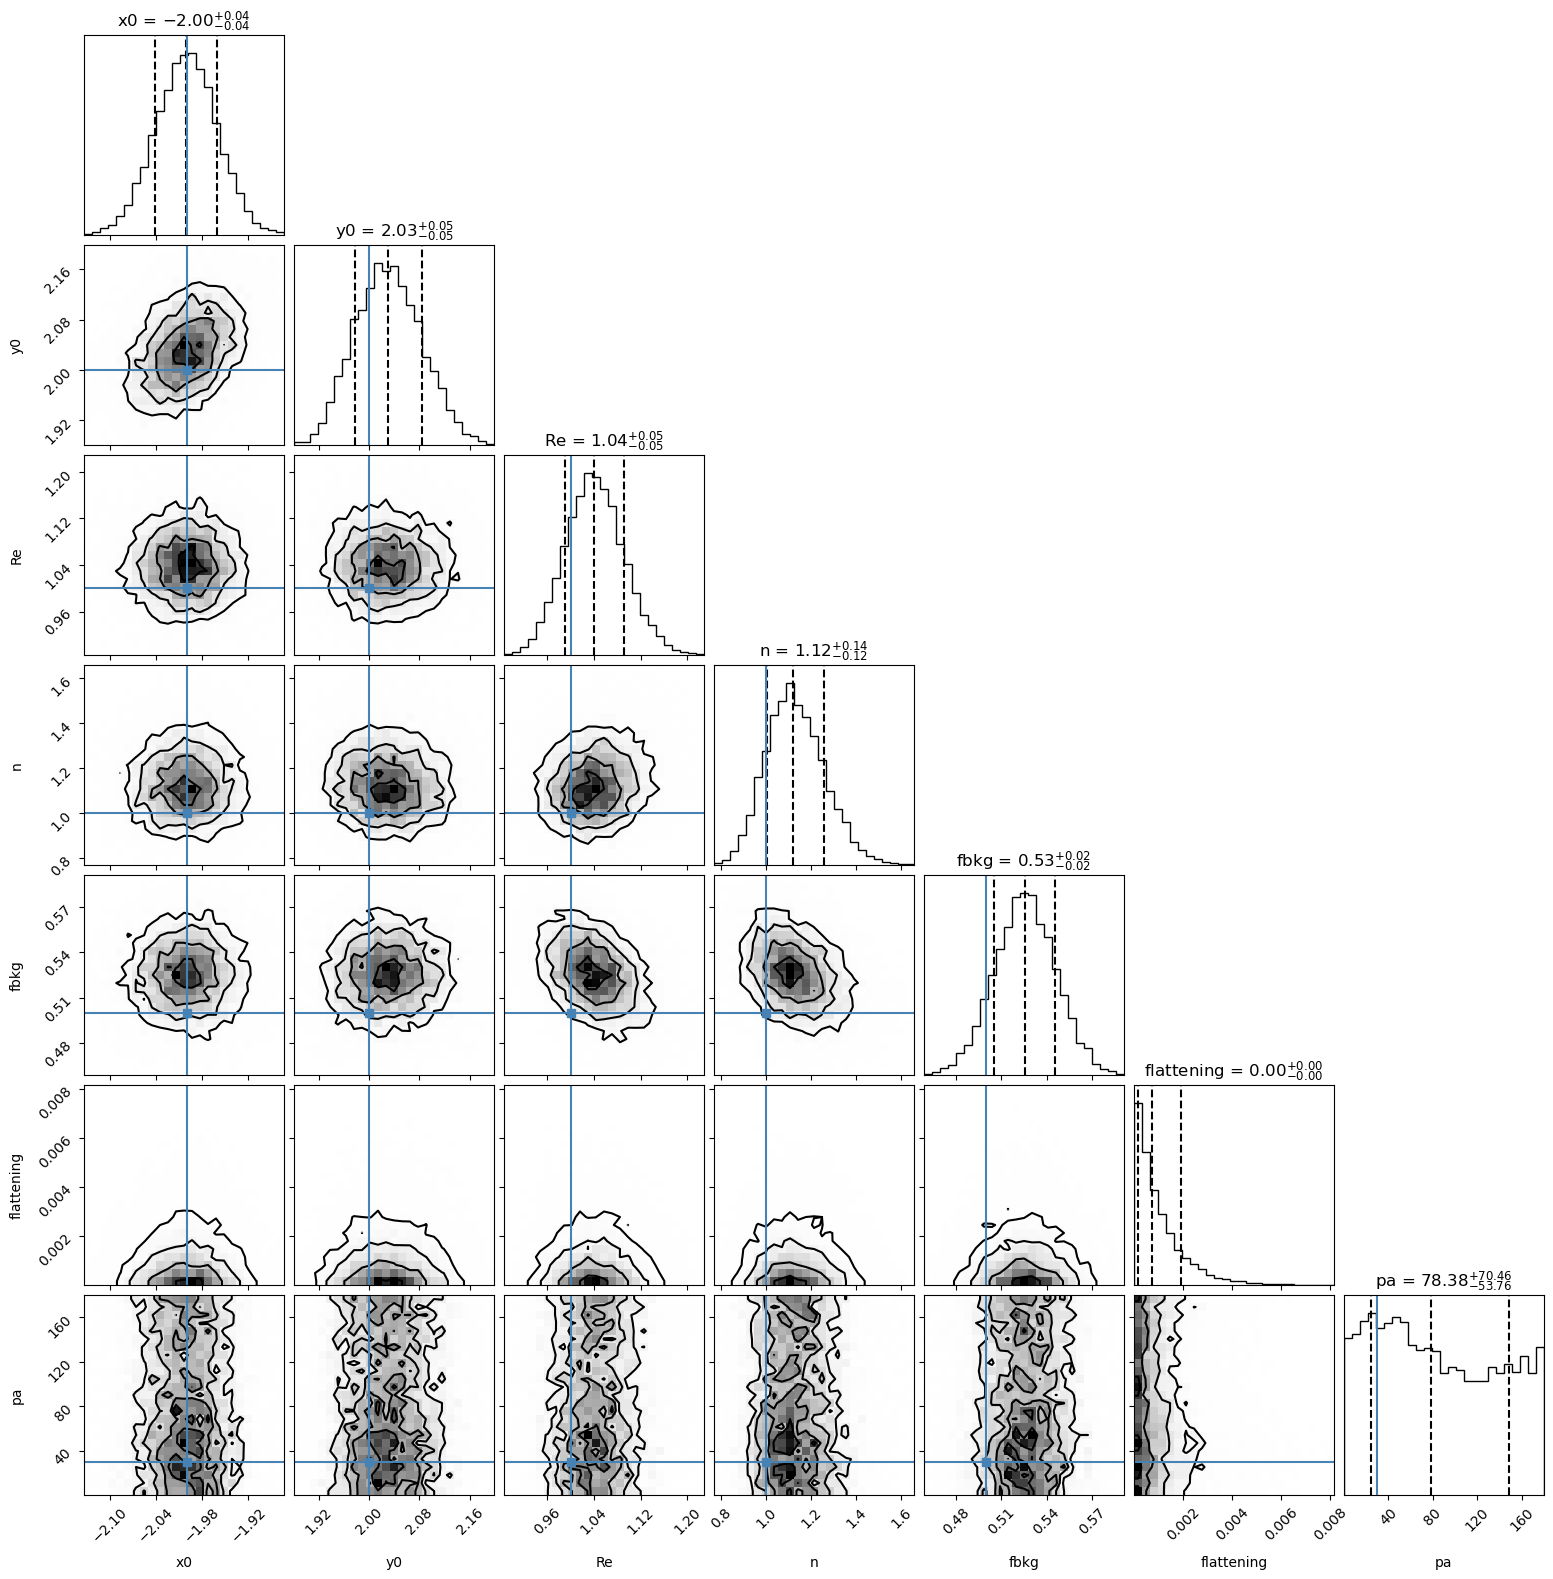

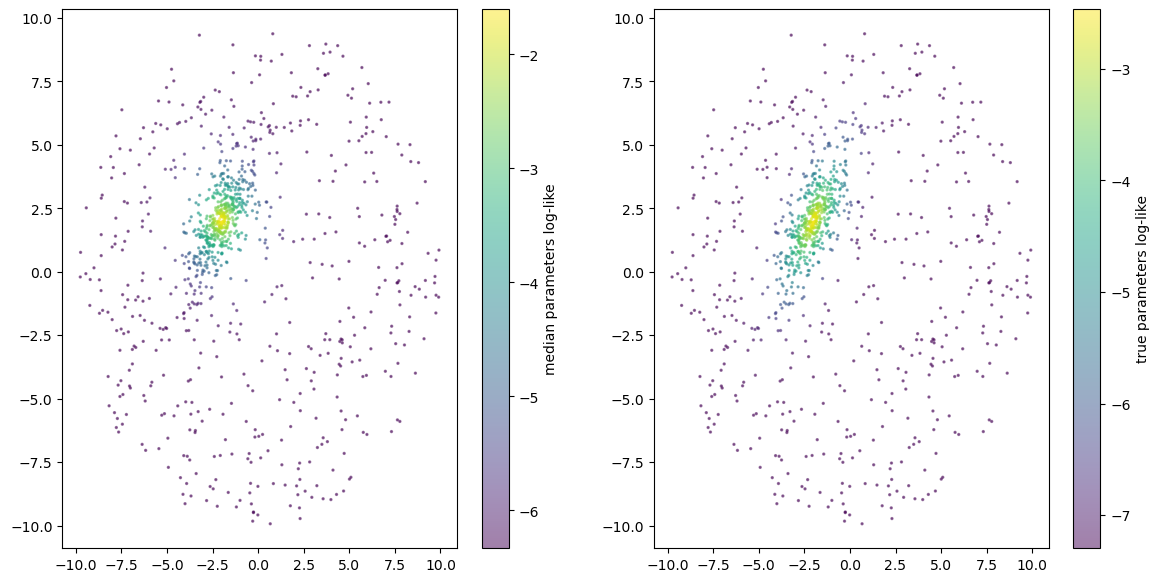

In [296]:
def plot_results(sampler, truths, showsky=True):
    points, log_w, log_l = sampler.posterior()
    w = np.exp(log_w)
    corner.corner(
        points, weights=w, bins=25, labels=sampler.prior.keys,
        plot_datapoints=False, range=np.repeat(0.999, len(sampler.prior.keys)), 
        quantiles=[0.16, 0.5, 0.84],
        show_titles=True,
        truths=truths)

    if showsky:
        _, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

        meddct = {k:v for k, v in zip(sampler.prior.keys, np.percentile(points, 50,  weights=w, method='inverted_cdf', axis=0))}

        sc1 = ax1.scatter(x, y, c=loglikes(meddct,data=(x, y), hull=xy_hull, n_per_segment=1000), s=2, alpha=.5)
        plt.colorbar(sc1, ax=ax1).set_label('median parameters log-like')

        sc2 = ax2.scatter(x, y, c=loglikes({k:v for k, v in zip(sampler.prior.keys, truths)},data=(x, y), hull=xy_hull, n_per_segment=1000), s=2, alpha=.5)
        plt.colorbar(sc2, ax=ax2).set_label('true parameters log-like')

plot_results(sampler, truths)

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 36     | 1        | 4        | 38988    | N/A    | 10359 | -5695.86 
Total time: 62.1s


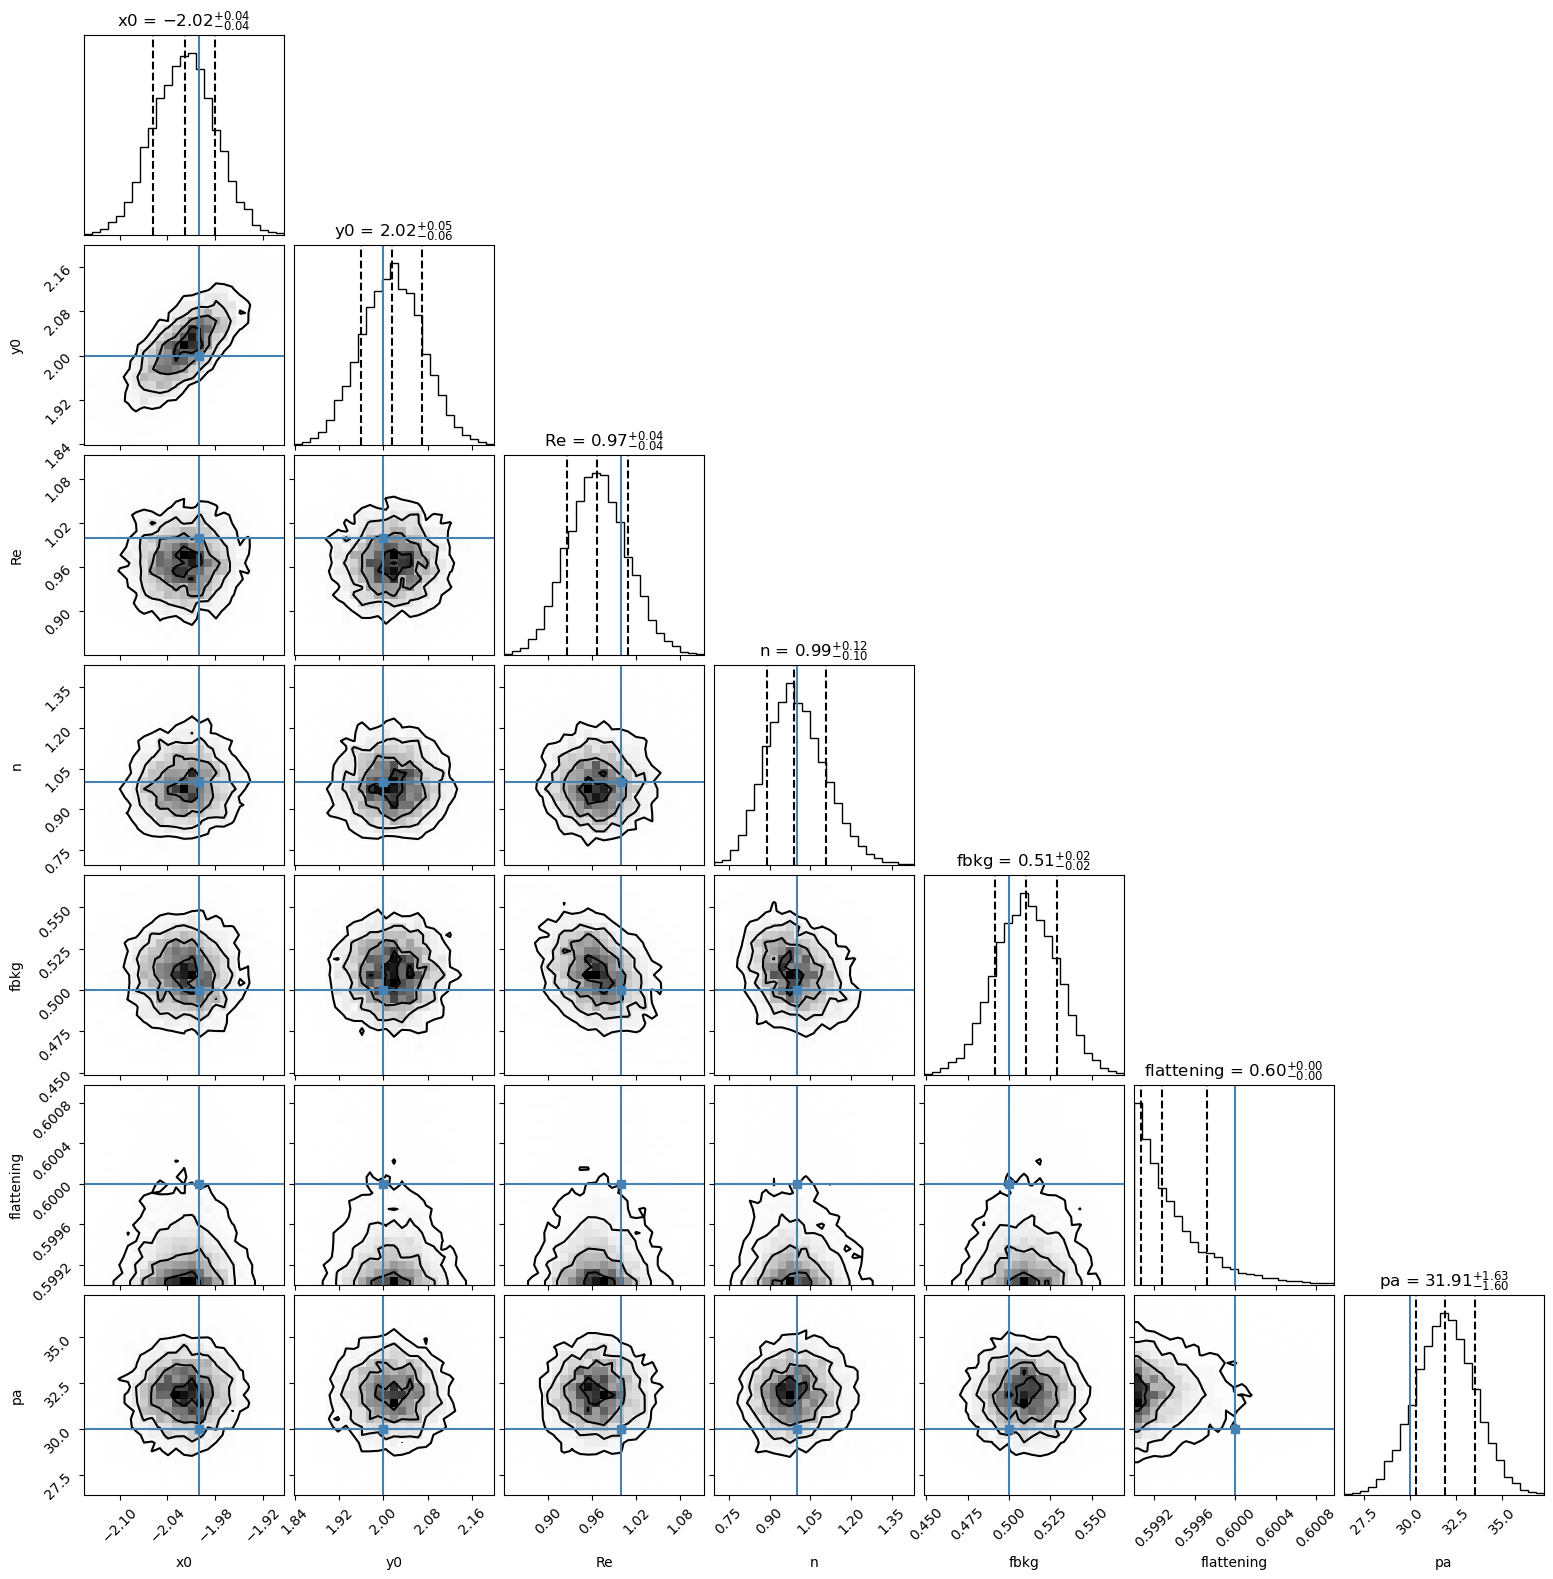

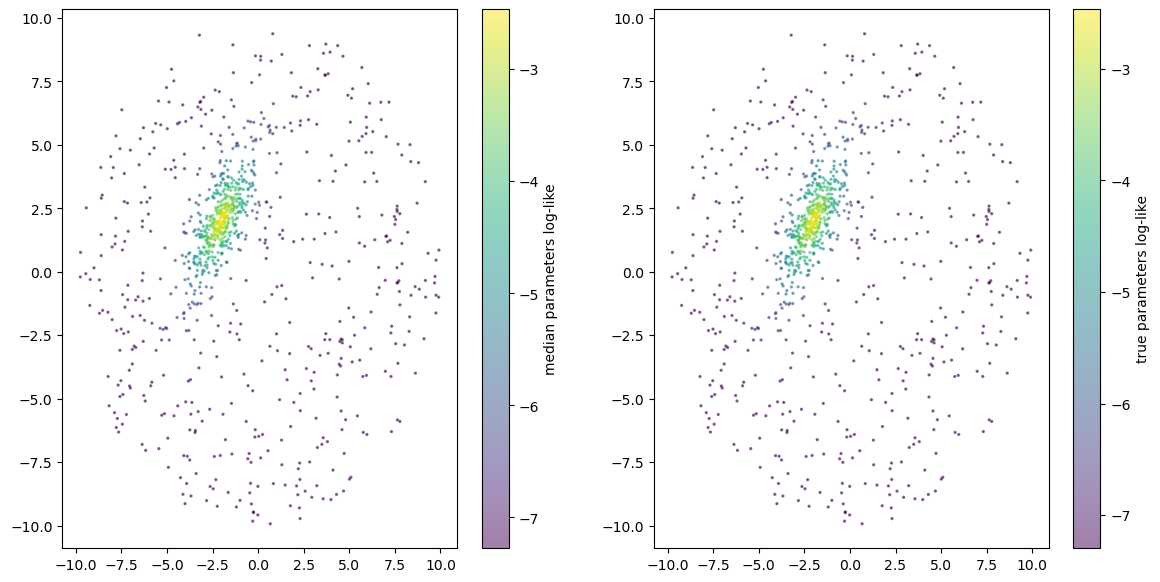

In [297]:
prior = nautilus.Prior()

prior.add_parameter('x0', (-2.5, 2.5))
prior.add_parameter('y0', (-2.5, 2.5))
prior.add_parameter('Re', (0.1, 2))
prior.add_parameter('n', (0.36, 4))
prior.add_parameter('fbkg', (0.1, 0.9))
prior.add_parameter('flattening', (0.599, .601))
prior.add_parameter('pa', (0, 180))

sampler = nautilus.Sampler(prior, loglike, 
                           likelihood_kwargs=dict(data=(x, y), hull=xy_hull, n_per_segment=1000),
                           n_live=1000, pool=12)
t_start = time.time()
sampler.run(verbose=True)
t_end = time.time()
print('Total time: {:.1f}s'.format(t_end - t_start))

plot_results(sampler, truths)

Hmm... issue with the flattening parameter. Reformulate. by trying different versions of `loglikes` c factors

''

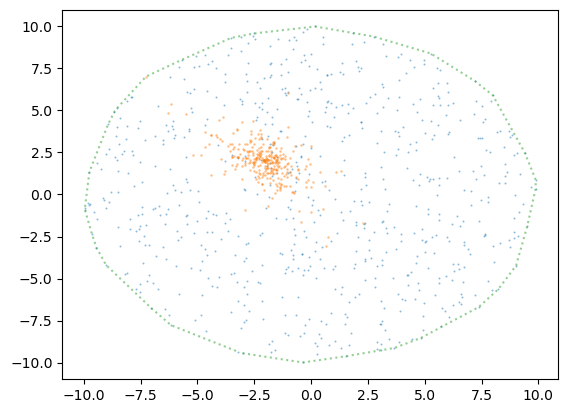

In [514]:
x0 = -2
y0 = 2
Re = 1
n = 1
fbkg = 0.7
flattening = 0.34
pa=140*u.deg

truths = [x0,y0,Re,n,fbkg,flattening,pa.to_value(u.deg)]

nstars = 1000
Router = 10

x, y, truenfg = sersic_plus_uniform_circle(nstars, fbkg, n=n, Re=Re, Router=Router, x0=x0, y0=y0, flattening=flattening, pa=pa)


xy_hull = spatial.ConvexHull(np.array((x, y)).T)

assert (nstars-truenfg) == fbkg*nstars, f'{nstars-truenfg} != {fbkg*nstars}'

plt.scatter(x[(truenfg-nstars):], y[(truenfg-nstars):], s=2, alpha=0.5, lw=0)
plt.scatter(x[:truenfg], y[:truenfg], s=3, alpha=0.5, lw=0)
plt.plot(*xy_hull.points[xy_hull.vertices].T, ':', alpha=.5, c='C2')
;

In [515]:
lastlls = None

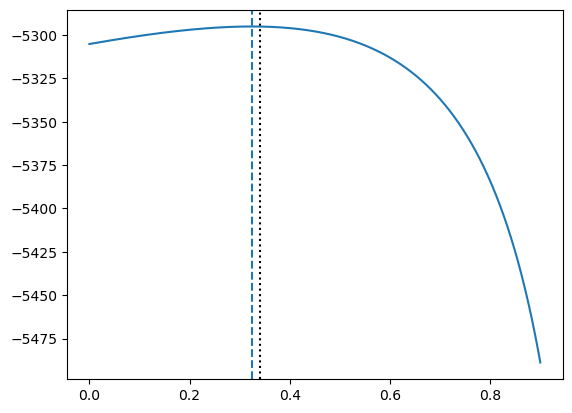

<Figure size 640x480 with 0 Axes>

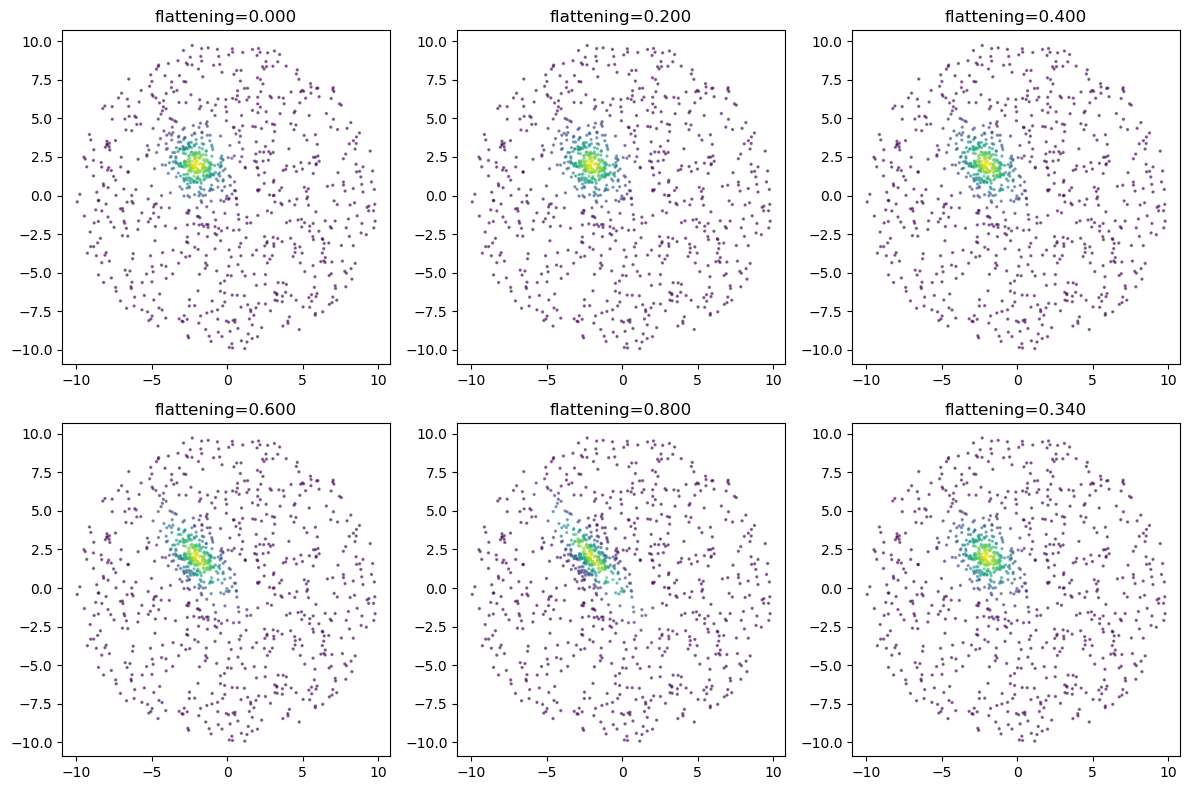

In [516]:
nstars = 1000
Router = 10

x, y, truenfg = sersic_plus_uniform_circle(nstars, fbkg, n=n, Re=Re, Router=Router, x0=x0, y0=y0, flattening=flattening, pa=pa)


xy_hull = spatial.ConvexHull(np.array((x, y)).T)



def loglikes(param_dict, data, hull, n_per_segment, noglx=False):
    x0 = param_dict['x0']
    y0 = param_dict['y0']
    Re = param_dict['Re']
    n = param_dict['n']
    fbkg = param_dict['fbkg']

    c = 1 - param_dict['flattening'] # = b/a
    a = Re/np.sqrt(c)

    parad = np.radians(param_dict['pa'])
    cpa = np.cos(parad)
    spa = np.sin(parad)

    xh, yh = hull.points.T
    # is the sign right here?
    xph = (xh*cpa + yh*spa)/c
    yph = -xh*spa + yh*cpa

    newhull = spatial.ConvexHull(np.array((xph, yph)).T)

    logbg = -np.log(hull.volume) #"volume" of a hull is actually 2d area THIS IS THE KEY DIFFERENCE!
    # should this be newhull.volume?

    if noglx:
        return logbg*np.ones_like(data[0])
    
    x = data[0] - x0
    y = data[1] - y0

    xp = ((x*cpa - y*spa))/c
    yp =  x*spa + y*cpa
    R = np.hypot(xp, yp)

    logfg = log_sersic_profile(R, 1, a, n) - np.log(sersic_integrate_hull(newhull, n_per_segment, n, a)) - np.log(c)
 
    return np.logaddexp(np.log(1-fbkg) + logfg, np.log(fbkg) + logbg)

fs = np.linspace(0,0.9,1000)
lls = []
pdct = {k:v for k, v in zip(sampler.prior.keys, truths)}
for f in fs:
    pdct['flattening'] = f
    lls.append(loglike(pdct,data=(x, y), hull=xy_hull, n_per_segment=1000))

plt.plot(fs, lls, '-')
plt.axvline(fs[np.argmax(lls)], c='C0', ls='--')
if lastlls is not None:
    plt.plot(fs, lastlls, '-')
    plt.axvline(fs[np.argmax(lastlls)], c='C1', ls='--')
plt.axvline(truths[-2], color='k', ls=':')
lastlls = lls


plt.figure()
fig, axs = plt.subplots(2, 3, figsize=(12,8))
for ax, f in zip(axs.flatten(), np.linspace(fs[0], 1, axs.size)):
    if f == 1:
        f = truths[-2]
    pdct['flattening'] = f
    ax.scatter(x, y, c=loglikes(pdct,data=(x, y), hull=xy_hull, n_per_segment=1000), s=2, alpha=.5)
    ax.set_title(f'flattening={f:.3f}')
fig.tight_layout()

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 32     | 1        | 4        | 36396    | N/A    | 10118 | -5310.52 
Total time: 57.4s


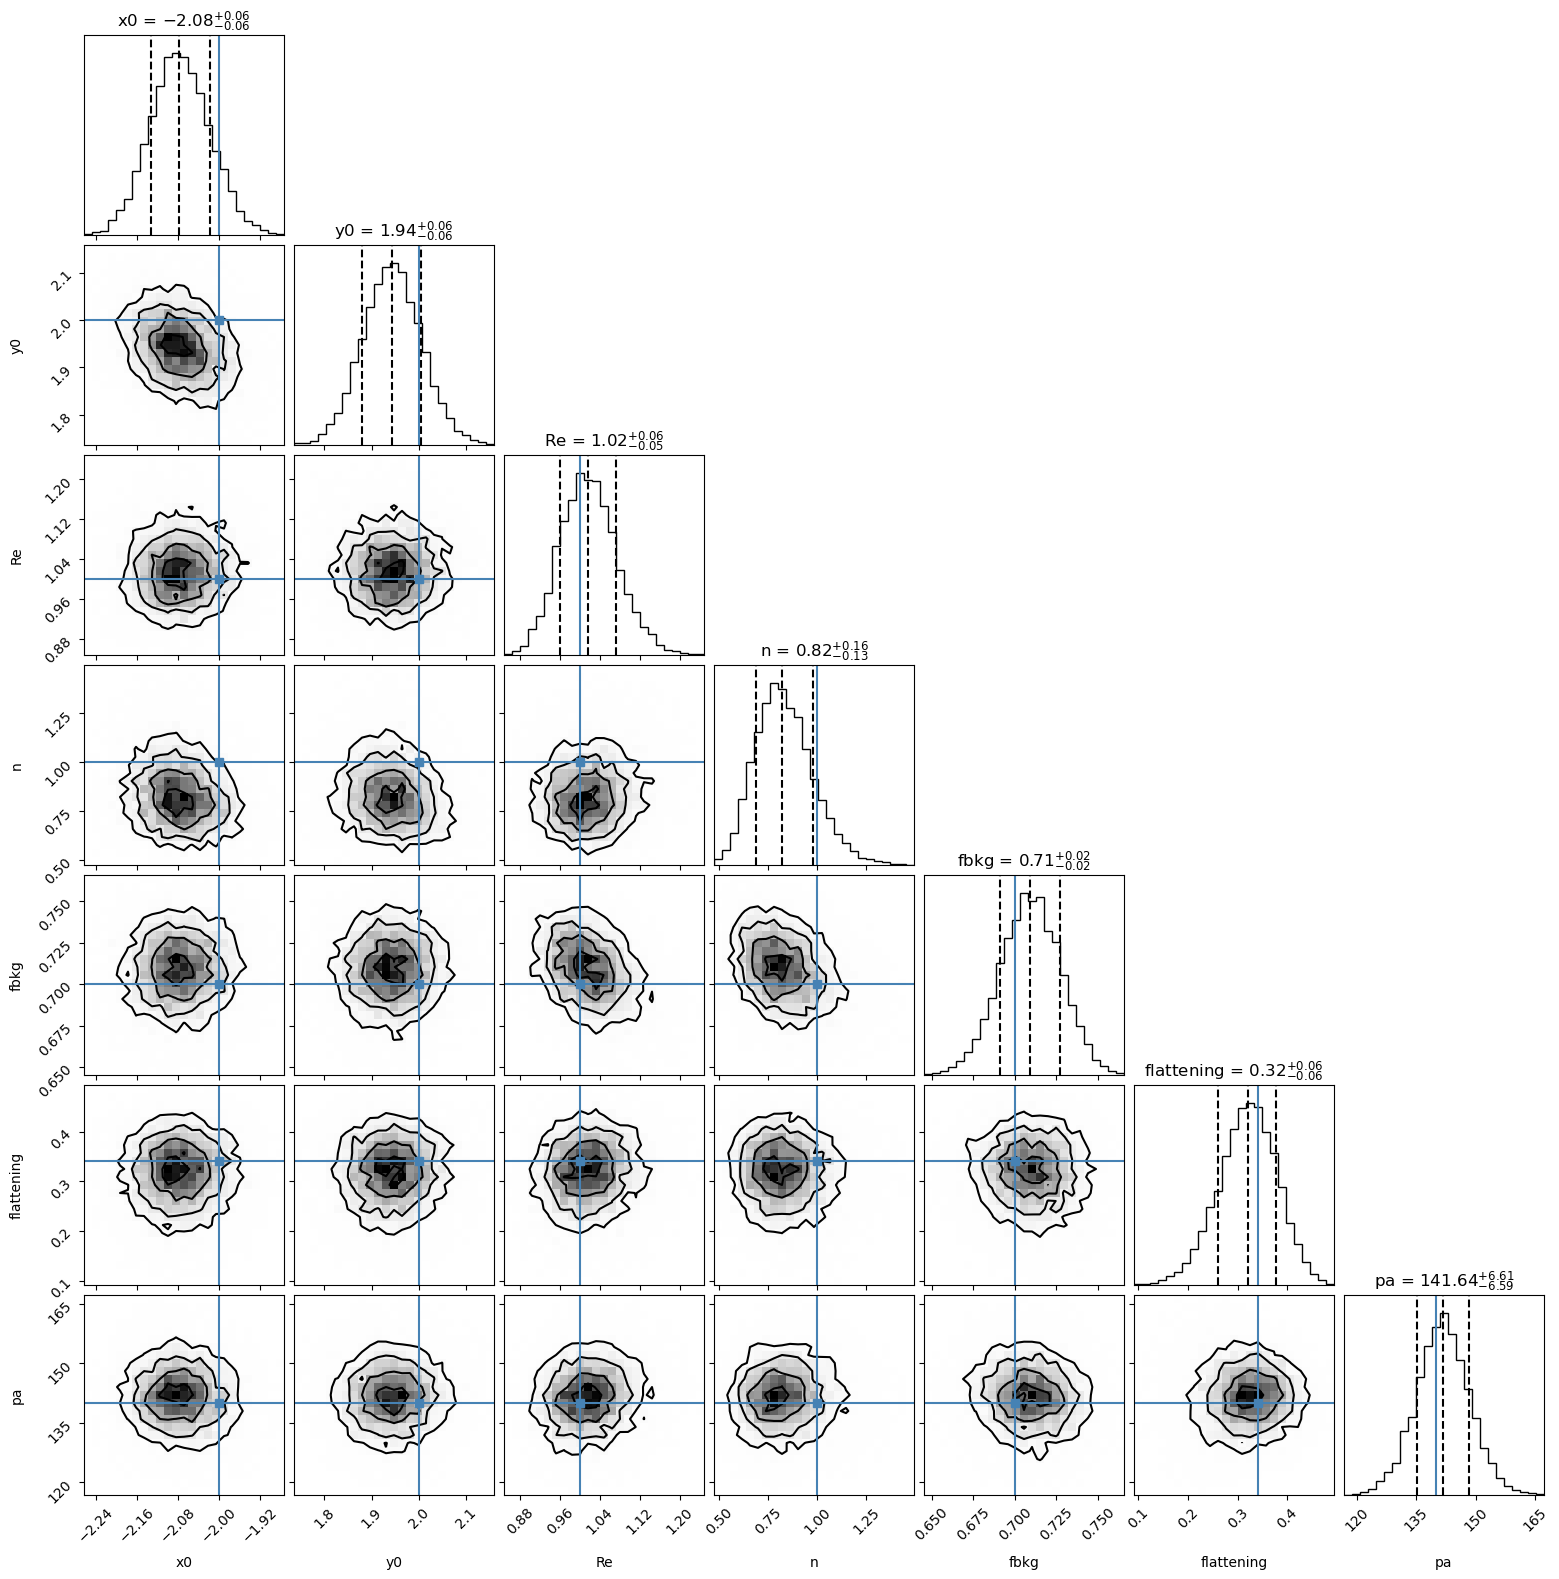

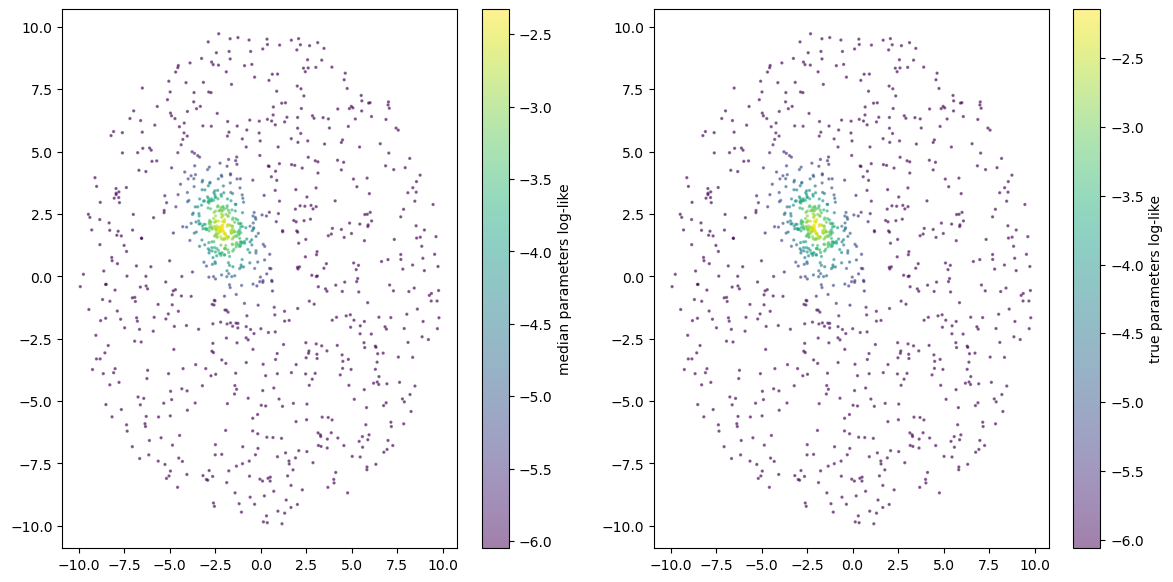

In [517]:
prior = nautilus.Prior()

prior.add_parameter('x0', (-2.5, 2.5))
prior.add_parameter('y0', (-2.5, 2.5))
prior.add_parameter('Re', (0.1, 2))
prior.add_parameter('n', (0.36, 4))
prior.add_parameter('fbkg', (0.1, 0.9))
prior.add_parameter('flattening', (0., .9))
prior.add_parameter('pa', (0, 180))

sampler = nautilus.Sampler(prior, loglike, 
                           likelihood_kwargs=dict(data=(x, y), hull=xy_hull, n_per_segment=1000),
                           n_live=1000, pool=12)
t_start = time.time()
sampler.run(verbose=True)
t_end = time.time()
print('Total time: {:.1f}s'.format(t_end - t_start))

plot_results(sampler, truths)